## Bibliotecas

In [ ]:
# https://pysus.readthedocs.io/pt/latest/databases/SINAN.html
!pip install -q PySUS

# GeoBR
!pip install -q geobr

In [1]:
import pandas as pd
import numpy as np
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import gc
import io
import requests
from pysus import SINAN
# from pysus.online_data.SINAN import download, list_diseases, get_available_years
from geobr import read_municipality
import geopandas as gpd
from shapely.geometry import MultiPolygon
from google.colab import auth, drive
import pyarrow
import fastparquet

# Configurando Drive

In [2]:
# Montar o Google Drive
try:
  drive.mount('/content/drive', force_remount=True)
  print("✅ Google Drive montado com sucesso.")
except Exception as e:
  print(f"❌ Erro ao montar o Google Drive: {e}")

Mounted at /content/drive
✅ Google Drive montado com sucesso.


In [3]:
def salvar_no_drive(df: pd.DataFrame, path_drive: str, format: str = "parquet"):
    """
    Salva um df em um diretório especificado no Google Drive.

    Args:
        df (pd.DataFrame): O df a ser salvo.
        path_drive (str): O caminho completo no Drive onde o arquivo será salvo,
                          incluindo o nome do arquivo e a extensão (ex: 'meu_diretorio/dados.parquet').
        format (str): O formato do arquivo a ser salvo ('parquet' ou 'csv'). Padrão é 'parquet'.
    """
    # 1. Definir o caminho completo no Drive
    # O Google Drive montado é acessível via '/content/drive/My Drive/'
    full_path = os.path.join('/content/drive/My Drive/', path_drive)

    # 2. Criar o diretório se não existir
    output_dir = os.path.dirname(full_path)
    if not os.path.exists(output_dir) and output_dir: # output_dir pode ser vazio se for na raiz
        try:
            os.makedirs(output_dir)
            print(f"📁 Diretório '{output_dir}' criado no Drive.")
        except Exception as e:
            print(f"❌ Erro ao criar diretório no Drive: {e}")
            return

    # 3. Salvar o DataFrame
    try:
        if format == "parquet":
            df.to_parquet(full_path, index=False)
            print(f"💾 DataFrame salvo em: '{full_path}' (formato Parquet)")
        elif format == "csv":
            df.to_csv(full_path, index=False)
            print(f"💾 DataFrame salvo em: '{full_path}' (formato CSV)")
        else:
            print(f"❌ Formato '{format}' não suportado. Use 'parquet' ou 'csv'.")
            return

    except Exception as e:
        print(f"❌ Erro ao salvar o DataFrame no Google Drive: {e}")

# Carregando GeoBR

In [4]:
# Obtendo municipios pelo geobr
mun = read_municipality(code_muni="all", year=2022)
mun['code_muni'] = mun['code_muni'].astype('Int64')
mun.head()

,code_muni,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,1100015,Alta Floresta D'oeste,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.96836 -12.13407, -61.96827..."
1,1100023,Ariquemes,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-63.18281 -10.13892, -63.18615..."
2,1100031,Cabixi,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.70518 -13.32474, -60.70904..."
3,1100049,Cacoal,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-61.3474 -11.50562, -61.34569 ..."
4,1100056,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,"MULTIPOLYGON (((-60.82417 -13.11156, -60.82289..."


# InfoDengue

O InfoDengue é alimentado pelo projeto AlertaDengue (Fiocruz e FGV), que há mais de 10 anos providencia dados sobre aborviroses em tempo real, a nível municipal.

O AlertaDengue utiliza dados de notificações de casos provenientes do Sistema de Informação de Agravos de Notificação ([SINAN](http://portalsinan.saude.gov.br/)) que então são consolidados em conjunto com dados metereológicos ([REDEMET](https://www.redemet.aer.mil.br/)) e demográficos ([IBGE](https://www.ibge.gov.br/pt/inicio.html)).

Neste notebook, fazemos o download dos dados consolidados pela API do [InfoDengue](https://info.dengue.mat.br/), mas também temos uma extração opcional dos dados brutos do SINAN.

## Documentação API
https://info.dengue.mat.br/services/api/doc

## Repositório no GitHub
https://github.com/AlertaDengue

## Extração

In [ ]:
%%time

# URL base da API
url = "https://info.dengue.mat.br/api/alertcity"

# Parâmetros fixos
params_base = {
    "disease": "dengue",
    "format": "csv",
    "ew_start": 1,
    "ew_end": 53,
    "ey_start": 2010,
    "ey_end": date.today().year
    }

# Criando dicionários
niveis_alerta = {
    1: 'Verde' ,
    2: 'Amarelo',
    3: 'Laranja',
    4: 'Vermelho'}

receptivos = { # indica receptividade climática ou probabilidade para se completar um ciclo de transmissão
    0: 'Desfavorável',
    1: 'Favorável',
    2: 'Favorável nesta semana e na semana passada',
    3: 'Favorável por pelo menos 3 semanas'}

transmissoes = { # evidência de transmissão sustentada
    0: 'Nenhuma evidência',
    1: 'Possível',
    2: 'Altamente Provável'}

colunas_renomear = {
    "nivel": "nivel_alerta",
    "p_inc100k":"tx_incidencia_100k",
    "pop":"estim_pop"
    }

colunas_excluir = ['Localidade_id',
                   'versao_modelo',
                   'tweet',
                   'id',
                   'casprov_est_min',
                   'casprov_est_max',
                   'casprov_est',
                   'casconf'
                   ]

# Listando municipios
geocode_list = mun['code_muni'].tolist()
total_munis = len(geocode_list)

# Loop de coleta pelos municípios e envio para GCS
for i, muni in enumerate(geocode_list, 1):
    params = params_base.copy()
    params["geocode"] = muni

    try:
        # Montar URL com parâmetros
        full_url = requests.Request('GET', url, params=params).prepare().url
        porcentagem = (i / total_munis) * 100
        print(f"🔄 ({i}/{total_munis}) {porcentagem:.1f}% - Coletando: {full_url}")

        # Ler os dados diretamente do link CSV
        df = pd.read_csv(full_url)
        df["cod_mun"] = muni

        # Renomeia, exclui e mapeia colunas
        df.rename(columns=colunas_renomear, inplace=True)
        df.drop(columns=[col for col in colunas_excluir if col in df.columns], inplace=True)
        df["nivel_alerta"] = df["nivel_alerta"].map(niveis_alerta)
        df["receptivo"] = df["receptivo"].map(receptivos)
        df["transmissao"] = df["transmissao"].map(transmissoes)

        # Define o diretório base no Google Drive
        base_drive_dir = "Portfólio/Dengue/dados_brutos/"

        # Gera o nome do arquivo com base no código do município
        # O formato será "[CODIGO_MUNICIPIO].parquet"
        file_name = f"{muni}.parquet"

        # Constrói o caminho completo do arquivo no Drive
        drive_filepath = os.path.join(base_drive_dir, file_name)

        # Salvando no Google Drive
        salvar_no_drive(df, drive_filepath, "parquet")

    except Exception as e:
        print(f"❌ Erro com município {muni}: {e}")

## Acessando dados

In [6]:
%%time

# Verificando se o Google Drive está montado
if not os.path.exists('/content/drive'):
    print("⚠️ O Google Drive não está montado. Montando agora...")
    try:
        drive.mount('/content/drive')
        print("✅ Google Drive montado com sucesso.")
    except Exception as e:
        print(f"❌ Erro ao montar o Google Drive: {e}")
        print("Por favor, monte o Google Drive manualmente antes de usar esta função.")

# Definindo o caminho base da pasta no Google Drive
drive_base_path = '/content/drive/My Drive/Portfólio/Dengue/dados_brutos/'

# Definindo colunas para baixar
colunas = ['data_iniSE', 'casos_est', 'casos', 'tx_incidencia_100k',
           'nivel_alerta', 'tempmin', 'umidmax', 'receptivo', 'transmissao',
           'nivel_inc', 'umidmed', 'umidmin', 'tempmed', 'tempmax', 'cod_mun']



# Listando todos os arquivos na pasta do Drive
try:
    all_files_in_dir = os.listdir(drive_base_path)
except FileNotFoundError:
    print(f"❌ Erro: O diretório '{drive_base_path}' não foi encontrado no Google Drive. Verifique o caminho.")

# Filtrando apenas arquivos .parquet
arquivos_parquet = [f for f in all_files_in_dir if f.endswith(".parquet")]

# Se não houver arquivos .parquet:
if not arquivos_parquet:
    print(f"🤷 Nenhum arquivo Parquet encontrado em '{drive_base_path}'.")
    dados_completos = pd.DataFrame(columns=colunas)
else:
    # Lista para armazenar os DataFrames lidos
    dfs = []
    total_arquivos = len(arquivos_parquet)

    # Loop para leitura dos arquivos
    for i, file_name in enumerate(arquivos_parquet, 1):
        # Construir o caminho completo para cada arquivo
        full_file_path = os.path.join(drive_base_path, file_name)
        # Ler o arquivo .parquet diretamente do caminho local
        try:
            df = pd.read_parquet(full_file_path, columns=colunas)
        except ValueError as e:
            print(f"⚠️ Erro ao ler {full_file_path}: {e}")
            continue  # Pula arquivos que não têm todas as colunas ou estão corrompidos

        porcentagem = (i / total_arquivos) * 100
        print(f"⬇️ Lendo ({i}/{total_arquivos}) - {porcentagem:.1f}%: {file_name}")
        dfs.append(df)

    # Concatena todos os DataFrames
    dados_completos = pd.concat(dfs, ignore_index=True)

print("\n✅ Leitura concluída. DataFrame concatenado com sucesso.")
dados_completos.head()

A saída de streaming foi truncada nas últimas 5000 linhas.
⬇️ Lendo (573/5572) - 10.3%: 5004700.parquet
⬇️ Lendo (574/5572) - 10.3%: 5004809.parquet
⬇️ Lendo (575/5572) - 10.3%: 5004908.parquet
⬇️ Lendo (576/5572) - 10.3%: 5005004.parquet
⬇️ Lendo (577/5572) - 10.4%: 5005103.parquet
⬇️ Lendo (578/5572) - 10.4%: 5005152.parquet
⬇️ Lendo (579/5572) - 10.4%: 5005202.parquet
⬇️ Lendo (580/5572) - 10.4%: 5005251.parquet
⬇️ Lendo (581/5572) - 10.4%: 5005400.parquet
⬇️ Lendo (582/5572) - 10.4%: 5005608.parquet
⬇️ Lendo (583/5572) - 10.5%: 5005681.parquet
⬇️ Lendo (584/5572) - 10.5%: 5005707.parquet
⬇️ Lendo (585/5572) - 10.5%: 5005806.parquet
⬇️ Lendo (586/5572) - 10.5%: 5006002.parquet
⬇️ Lendo (587/5572) - 10.5%: 5006200.parquet
⬇️ Lendo (588/5572) - 10.6%: 5006259.parquet
⬇️ Lendo (589/5572) - 10.6%: 5006275.parquet
⬇️ Lendo (590/5572) - 10.6%: 5006309.parquet
⬇️ Lendo (591/5572) - 10.6%: 5006358.parquet
⬇️ Lendo (592/5572) - 10.6%: 5006408.parquet
⬇️ Lendo (593/5572) - 10.6%: 5006606.parq

<timed exec>:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



✅ Leitura concluída. DataFrame concatenado com sucesso.
CPU times: user 39 s, sys: 4.43 s, total: 43.4 s
Wall time: 58.8 s


,data_iniSE,casos_est,casos,tx_incidencia_100k,nivel_alerta,tempmin,umidmax,receptivo,transmissao,nivel_inc,umidmed,umidmin,tempmed,tempmax,cod_mun
0,2025-06-01,0.0,0,0.000000,Verde,11.547100,95.307125,Desfavorável,Nenhuma evidência,0,86.545025,71.581850,14.985075,20.100775,4217758
1,2025-05-25,0.0,0,0.000000,Verde,11.089843,89.724929,Desfavorável,Nenhuma evidência,0,78.922943,65.522743,14.691929,18.889614,4217758
2,2025-05-18,1.0,1,34.746353,Verde,17.119100,94.234786,Favorável,Nenhuma evidência,0,86.275671,73.930000,19.234757,22.603514,4217758
3,2025-05-11,3.0,3,104.239050,Verde,13.926886,85.833200,Desfavorável,Nenhuma evidência,0,73.930300,55.436757,17.670814,23.044514,4217758
4,2025-05-04,1.0,1,34.746353,Verde,17.124929,91.678329,Favorável,Nenhuma evidência,0,76.552829,57.246786,20.460371,25.166186,4217758


## Merge com GeoBR

In [7]:
dados_completos = pd.merge(dados_completos, mun,
                           left_on='cod_mun',
                           right_on='code_muni',
                           how='left')

dados_completos = dados_completos.drop(columns=['code_muni'])

dados_completos.head()

,data_iniSE,casos_est,casos,tx_incidencia_100k,nivel_alerta,tempmin,umidmax,receptivo,transmissao,nivel_inc,...,tempmed,tempmax,cod_mun,name_muni,code_state,abbrev_state,name_state,code_region,name_region,geometry
0,2025-06-01,0.0,0,0.000000,Verde,11.547100,95.307125,Desfavorável,Nenhuma evidência,0,...,14.985075,20.100775,4217758,Sul Brasil,42.0,SC,Santa Catarina,4.0,Sul,"MULTIPOLYGON (((-52.96458 -26.74871, -52.96966..."
1,2025-05-25,0.0,0,0.000000,Verde,11.089843,89.724929,Desfavorável,Nenhuma evidência,0,...,14.691929,18.889614,4217758,Sul Brasil,42.0,SC,Santa Catarina,4.0,Sul,"MULTIPOLYGON (((-52.96458 -26.74871, -52.96966..."
2,2025-05-18,1.0,1,34.746353,Verde,17.119100,94.234786,Favorável,Nenhuma evidência,0,...,19.234757,22.603514,4217758,Sul Brasil,42.0,SC,Santa Catarina,4.0,Sul,"MULTIPOLYGON (((-52.96458 -26.74871, -52.96966..."
3,2025-05-11,3.0,3,104.239050,Verde,13.926886,85.833200,Desfavorável,Nenhuma evidência,0,...,17.670814,23.044514,4217758,Sul Brasil,42.0,SC,Santa Catarina,4.0,Sul,"MULTIPOLYGON (((-52.96458 -26.74871, -52.96966..."
4,2025-05-04,1.0,1,34.746353,Verde,17.124929,91.678329,Favorável,Nenhuma evidência,0,...,20.460371,25.166186,4217758,Sul Brasil,42.0,SC,Santa Catarina,4.0,Sul,"MULTIPOLYGON (((-52.96458 -26.74871, -52.96966..."


## Visualização Inicial

In [8]:
dados_completos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4478573 entries, 0 to 4478572
Data columns (total 22 columns):
 #   Column              Dtype   
---  ------              -----   
 0   data_iniSE          object  
 1   casos_est           float64 
 2   casos               object  
 3   tx_incidencia_100k  float64 
 4   nivel_alerta        object  
 5   tempmin             float64 
 6   umidmax             float64 
 7   receptivo           object  
 8   transmissao         object  
 9   nivel_inc           object  
 10  umidmed             float64 
 11  umidmin             float64 
 12  tempmed             float64 
 13  tempmax             float64 
 14  cod_mun             int64   
 15  name_muni           object  
 16  code_state          float64 
 17  abbrev_state        object  
 18  name_state          object  
 19  code_region         float64 
 20  name_region         object  
 21  geometry            geometry
dtypes: float64(10), geometry(1), int64(1), object(10)
memory usage: 75

In [9]:
dados_completos = dados_completos.astype({
    'casos': 'Int64',
    'nivel_inc': 'Int64',
    'code_state': 'Int64',
    'code_region': 'Int64'
})

### Nulos

In [10]:
# Valores ausentes
def resumo_nulos(df):
    nulos = df.isnull().sum()
    nulos_porcentagem = (nulos / len(df)) * 100
    return pd.DataFrame({
        'Total': nulos,
        'Porcentagem': nulos_porcentagem
    }).query("Total > 0").sort_values(by='Total', ascending=False)

resumo_nulos(dados_completos)

,Total,Porcentagem
umidmed,397401,8.873384
tempmed,395814,8.837949
tempmax,395814,8.837949
umidmin,382278,8.535710
umidmax,329712,7.361988
tempmin,202626,4.524343
receptivo,2467,0.055085
transmissao,1806,0.040325


In [11]:
# Lista de variáveis meteorológicas
variaveis_meterologicas = ['tempmed', 'umidmed', 'tempmax', 'tempmin', 'umidmax', 'umidmin']

# Cria uma cópia dos dados para imputar
dados_completos_mod = dados_completos.copy()

# Loop de imputação por média do município
for coluna in variaveis_meterologicas:
    print(f"Imputando coluna: {coluna} com média por município (cod_mun)")
    dados_completos_mod[coluna] = (
        dados_completos_mod.groupby("cod_mun")[coluna]
        .transform(lambda x: x.fillna(x.mean()))
    )
    gc.collect()

Imputando coluna: tempmed com média por município (cod_mun)
Imputando coluna: umidmed com média por município (cod_mun)
Imputando coluna: tempmax com média por município (cod_mun)
Imputando coluna: tempmin com média por município (cod_mun)
Imputando coluna: umidmax com média por município (cod_mun)
Imputando coluna: umidmin com média por município (cod_mun)


In [12]:
resumo_nulos(dados_completos_mod)

,Total,Porcentagem
receptivo,2467,0.055085
transmissao,1806,0.040325


### Descritivas

In [13]:
# Descritivas
descritivas = dados_completos_mod.describe().T
pd.options.display.float_format = '{:.2f}'.format
descritivas

,count,mean,std,min,25%,50%,75%,max
casos_est,4478573.00,8.02,168.03,0.00,0.00,0.00,1.00,85389.00
casos,4478573.00,7.98,167.74,0.00,0.00,0.00,1.00,85389.00
tx_incidencia_100k,4478573.00,19.71,99.47,0.00,0.00,0.00,4.29,7103.06
tempmin,4478573.00,20.07,4.13,-0.50,17.57,20.59,23.29,38.00
umidmax,4478573.00,88.21,14.42,13.00,83.27,90.68,95.44,14025.78
nivel_inc,4478573.00,0.17,0.50,0.00,0.00,0.00,0.00,2.00
umidmed,4478573.00,72.99,12.81,13.00,64.92,74.76,82.34,1155.22
umidmin,4478573.00,55.76,16.60,4.57,43.91,55.43,66.86,162.86
tempmed,4478573.00,23.54,3.94,1.97,21.17,24.11,26.48,38.44
tempmax,4478573.00,27.40,4.61,3.40,24.57,27.86,30.71,69.86


* casos_est, casos e tx_incidencia_100k possuem médias próximas, e outras métricas refletem a sazonalidade da doença
* valores de umidade acima de 100% são fisicamente impossíveis no contexto meteorológico normal (exceto talvez em situações muito específicas e breves de super saturação, mas quase sempre são erros de medição ou registro)
* temperaturas máximas muito altas, como 69°C, são extremamente improváveis para o Brasil e provavelmente indicam erros nos dados (problemas na coleta, entrada, ou valores outliers).

### Outliers

In [14]:
# Umidade relativa máxima: limites aceitáveis entre 0% e 100%
dados_completos_mod = dados_completos_mod[(dados_completos_mod['umidmax'] >= 0) & (dados_completos_mod['umidmax'] <= 100)]
dados_completos_mod = dados_completos_mod[(dados_completos_mod['umidmin'] >= 0) & (dados_completos_mod['umidmin'] <= 100)]

# Temperatura máxima: considerando valores plausíveis para o Brasil, por exemplo entre -18°C e 45°C
# A maior temperatura já registrada pelo INMET foi 44,8°C em Araçuaí (2023), e a menor foi -17,8°C em Morro da Igreja (1996)
dados_completos_mod = dados_completos_mod[(dados_completos_mod['tempmax'] <= 45)]

## Qual a relação da Dengue com o clima?
* Maior precipitação e maior temperatura favorecem o aumento da reprodução dos mosquitos, logo, é de se esperar um aumento no número de casos. No entando, **condições climáticas adequadas** podem variar de lugar para lugar.
  * No Rio de Janeiro, por exemplo, temperatura maior que 22 graus é condição necessária para transmissão sustentada. Em Fortaleza, umidade máxima acima de 85% é a condição necessária.
* No site do InfoDengue, temos o dicionário da coluna nivel_alerta
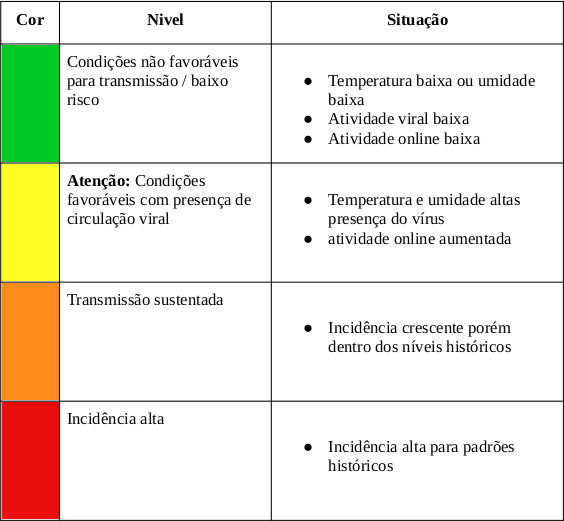

O esperado é de picos de casos após alguns meses de calor e chuvosos, e numeros baixos de casos em meses mais secos e frios

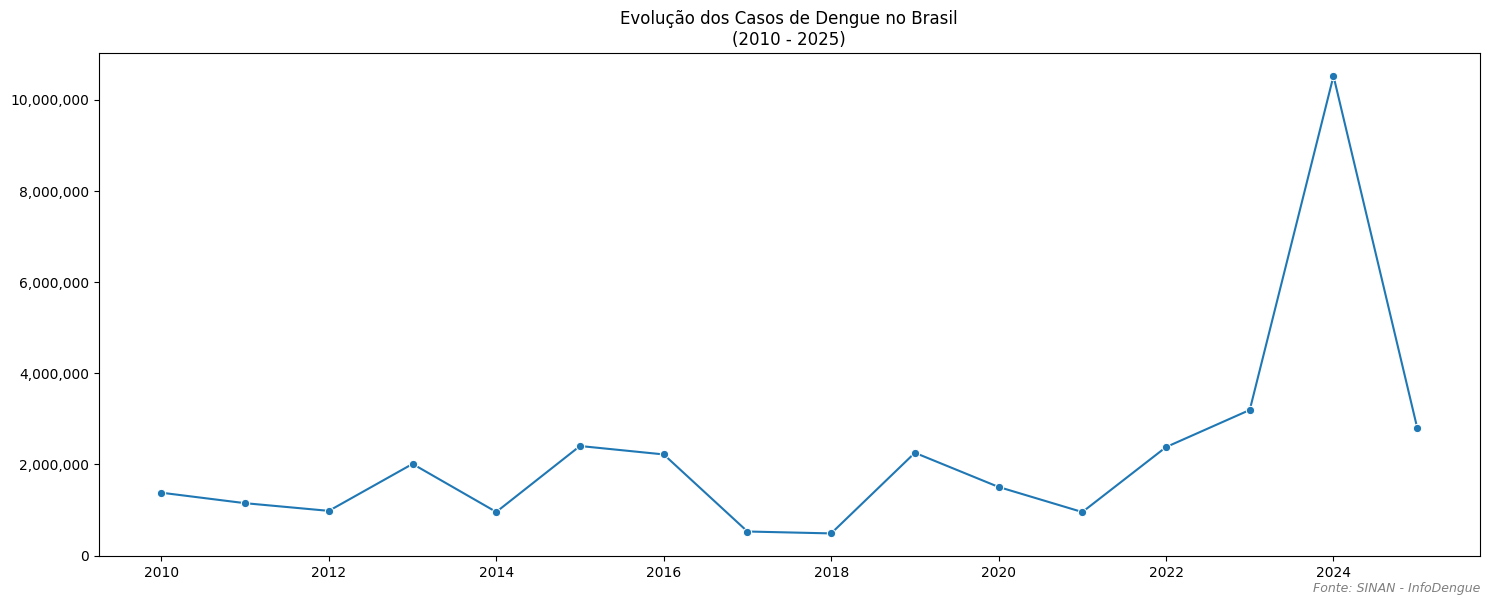

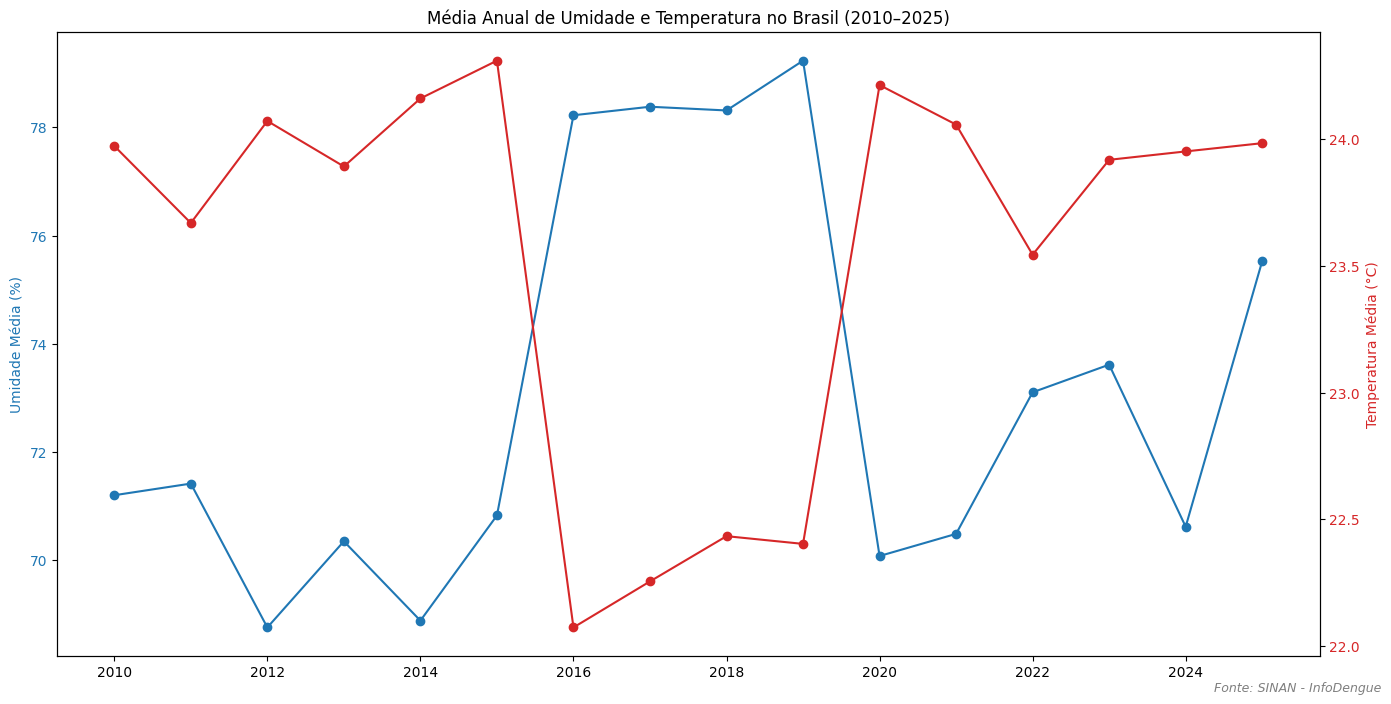

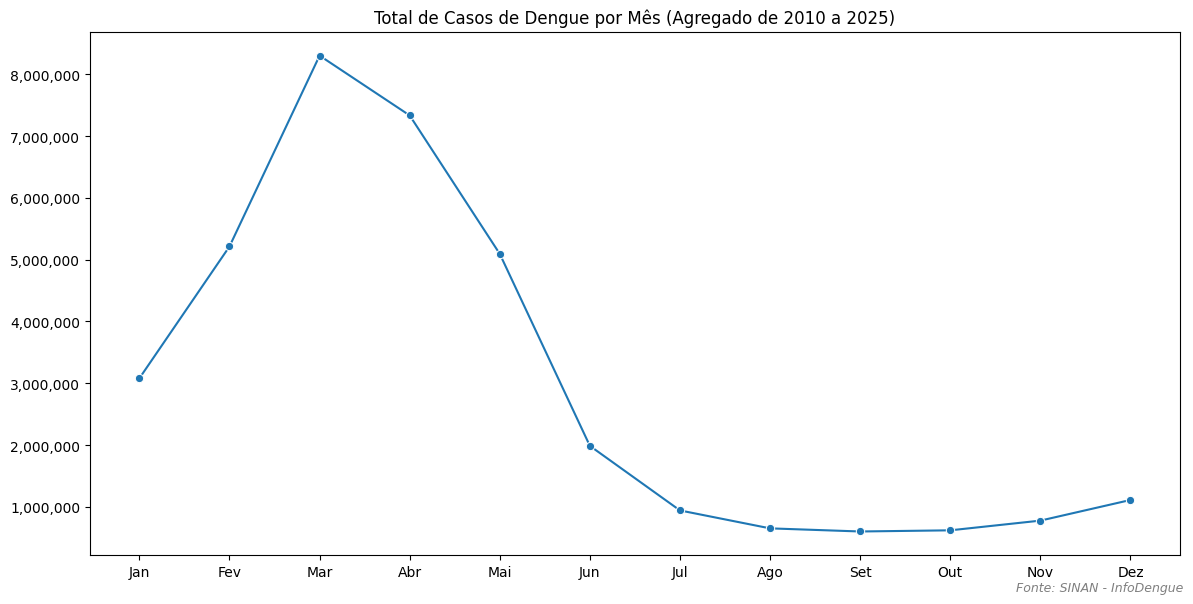

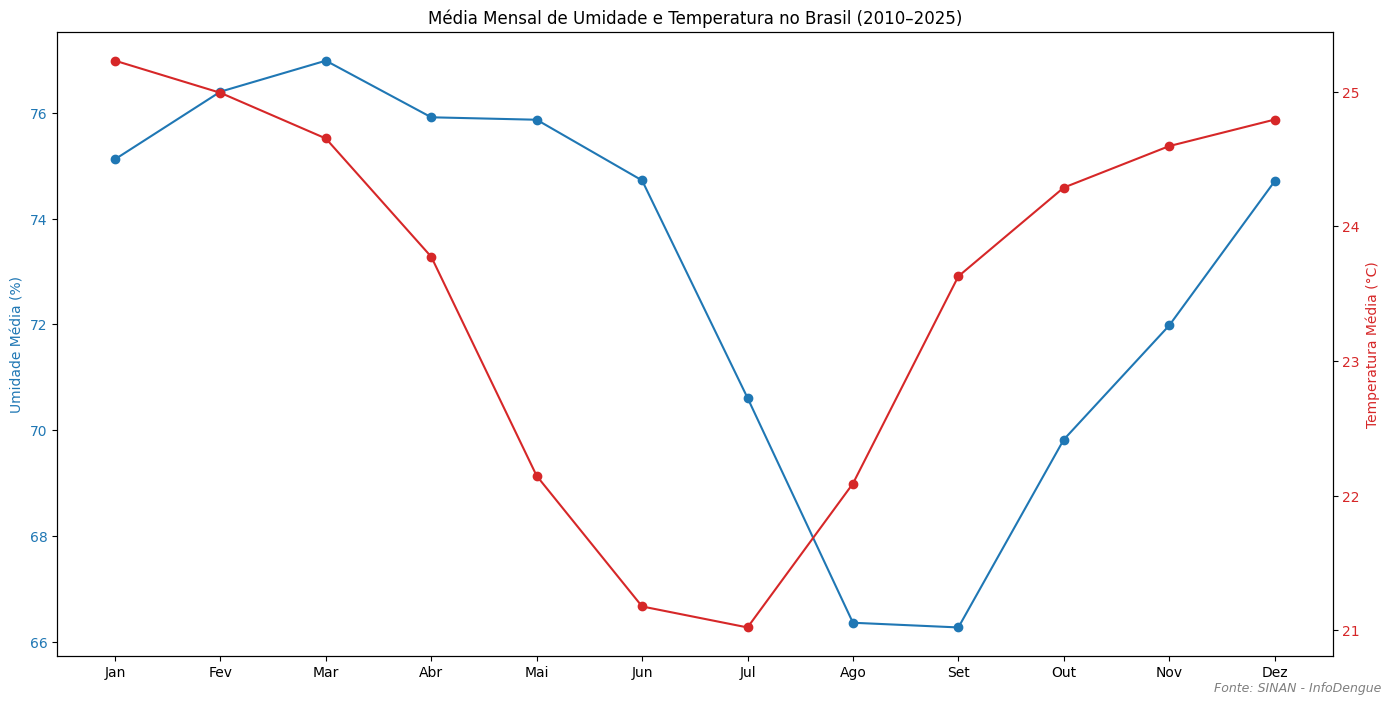

In [15]:
## Preparando dados ============================================================

# Convertendo para datetime e ordenando
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])
dados_completos_mod = dados_completos_mod.sort_values('data_iniSE')
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year
dados_completos_mod['mes'] = dados_completos_mod['data_iniSE'].dt.month

# Agrupar casos por ano
df_ano_casos = dados_completos_mod.groupby('ano')['casos'].sum().reset_index()

# Agrupar por mês e somar os casos
df_mes_casos = dados_completos_mod.groupby('mes')['casos'].sum().reset_index().sort_values('mes')

# Mapear números dos meses para nomes
meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
df_mes_casos['mes_nome'] = df_mes_casos['mes'].map(meses)

# Calcular a média de 'umidmed' e 'tempmed' por ano
df_anual = dados_completos_mod.groupby('ano')[['umidmed', 'tempmed']].mean().reset_index()

# Calcular a média de umidmed e tempmed por mês
df_mensal = dados_completos_mod.groupby('mes')[['umidmed', 'tempmed']].mean().reset_index()
df_mensal['mes_nome'] = df_mensal['mes'].map(meses)

# Cores diferentes para cada variável
cor_umid = 'tab:blue'
cor_temp = 'tab:red'

### Evolução de casos no Brasil ================================================
plt.figure(figsize=(15, 6))

sns.lineplot(data=df_ano_casos, x='ano', y='casos', marker='o')

plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.title('Evolução dos Casos de Dengue no Brasil\n(2010 - 2025)')

plt.figtext(0.99, 0.005,
            "Fonte: SINAN - InfoDengue",
            ha='right', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

### Temperatura Média x Umidade Média: Nacional ================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Eixo Y primário (umidade)
ax1.set_xlabel('')
ax1.set_ylabel('Umidade Média (%)', color=cor_umid)
ax1.plot(df_anual['ano'], df_anual['umidmed'], color=cor_umid, marker='o', label='Umidade Média')
ax1.tick_params(axis='y', labelcolor=cor_umid)

# Eixo Y secundário (temperatura)
ax2 = ax1.twinx()
ax2.set_ylabel('Temperatura Média (°C)', color=cor_temp)
ax2.plot(df_anual['ano'], df_anual['tempmed'], color=cor_temp, marker='o', label='Temperatura Média')
ax2.tick_params(axis='y', labelcolor=cor_temp)

# Título e fonte
plt.title('Média Anual de Umidade e Temperatura no Brasil (2010–2025)')
plt.figtext(0.99, 0.005,
            "Fonte: SINAN - InfoDengue",
            ha='right', fontsize=9, style='italic', color='gray')

fig.tight_layout()
plt.show()

### Evolução de casos no Brasil por Mês ========================================
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_mes_casos, x='mes_nome', y='casos', marker='o')

plt.xlabel('')
plt.ylabel('')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.title('Total de Casos de Dengue por Mês (Agregado de 2010 a 2025)')

plt.figtext(0.99, 0.005,
            "Fonte: SINAN - InfoDengue",
            ha='right', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

### Temperatura Média x Umidade Média por Mês: Nacional ========================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Eixo Y primário (umidade)
ax1.set_xlabel('')
ax1.set_ylabel('Umidade Média (%)', color=cor_umid)
ax1.plot(df_mensal['mes_nome'], df_mensal['umidmed'], color=cor_umid, marker='o', label='Umidade Média')
ax1.tick_params(axis='y', labelcolor=cor_umid)

# Eixo Y secundário (temperatura)
ax2 = ax1.twinx()
ax2.set_ylabel('Temperatura Média (°C)', color=cor_temp)
ax2.plot(df_mensal['mes_nome'], df_mensal['tempmed'], color=cor_temp, marker='o', label='Temperatura Média')
ax2.tick_params(axis='y', labelcolor=cor_temp)

# Título e fonte
plt.title('Média Mensal de Umidade e Temperatura no Brasil (2010–2025)')
plt.figtext(0.99, 0.005,
            "Fonte: SINAN - InfoDengue",
            ha='right', fontsize=9, style='italic', color='gray')

fig.tight_layout()
plt.show()

# Gerando Tabelas para Flourish

In [16]:
# Caminho para salvar
flourish_filepath = "/content/drive/My Drive/Portfólio/Dengue/tabelas_flourish/"

In [ ]:
# Resumo Geral =================================================================
# Garantir que 'data_iniSE' esteja em datetime
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])

# Extrair ano e mês
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year
dados_completos_mod['mes'] = dados_completos_mod['data_iniSE'].dt.month

# Agrupar por ano, mês, UF e município
tabela_agregada = (
    dados_completos_mod
    .groupby([
        # 'ano',
        'mes',
        'name_region',
        'name_state',
        # 'name_muni'
        ], as_index=False).agg({
            'casos': 'sum',
            'umidmed': 'mean',
            'tempmed': 'mean'
            })
)

# Mapear números dos meses para nomes
meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
tabela_agregada['mes'] = tabela_agregada['mes'].map(meses)

# Salvando
filename = "tabela_geral.csv"
full_path = os.path.join(flourish_filepath, filename)
salvar_no_drive(tabela_agregada, full_path, "csv")

# Exibindo
tabela_agregada.head()

💾 DataFrame salvo em: '/content/drive/My Drive/Portfólio/Dengue/tabelas_flourish/tabela_geral.csv' (formato CSV)


,mes,name_region,name_state,casos,umidmed,tempmed
0,Jan,Centro Oeste,Distrito Federal,103784,73.75,22.38
1,Jan,Centro Oeste,GoiÃ¡s,273550,77.21,22.73
2,Jan,Centro Oeste,Mato Grosso,97433,78.26,26.27
3,Jan,Centro Oeste,Mato Grosso do Sul,124762,72.39,26.75
4,Jan,Nordeste,Alagoas,12572,81.12,25.57


In [ ]:
# Total de Casos por Ano e Mês =================================================

# Garantir que 'data_iniSE' esteja em datetime
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])

# Extrair ano e mês
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year
dados_completos_mod['mes_num'] = dados_completos_mod['data_iniSE'].dt.month

# Agrupar por ano e mês e somar casos
df_1 = (
    dados_completos_mod
    .groupby(['ano', 'mes_num'], as_index=False)
    .agg({'casos': 'sum'})
)

# Mapear número do mês para nome
meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
df_1['mes_nome'] = df_1['mes_num'].map(meses)

# Pivotar com mes_nome como coluna (sem ser índice)
df_1 = df_1.pivot_table(index='mes_nome', columns='ano', values='casos', aggfunc='sum').reset_index()

# Reordenar os meses corretamente
ordem_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
df_1['ordem'] = df_1['mes_nome'].apply(lambda x: ordem_meses.index(x))
df_1 = df_1.sort_values('ordem').drop(columns='ordem')

# Salvando
filename = "casos_por_ano_e_mes.csv"
full_path = os.path.join(flourish_filepath, filename)
salvar_no_drive(df_1, full_path, "csv")

# Exibindo
df_1.head()

💾 DataFrame salvo em: '/content/drive/My Drive/Portfólio/Dengue/tabelas_flourish/casos_por_ano_e_mes.csv' (formato CSV)


ano,mes_nome,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
4,Jan,167734,127325,91648,195805,54897,110813,409549,71316,42766,106360,177960,77463,124587,195195,724106,403703
3,Fev,212586,163954,92855,330362,81058,247020,563068,66060,47199,189002,311129,104793,145479,312026,1774860,572463
8,Mar,256705,213044,135960,648764,162266,604359,491332,74304,58107,410268,338732,136667,354373,589218,2973846,852724
0,Abr,236685,220936,218854,410806,211350,514049,359447,86166,82855,499740,208762,165366,544633,835322,2165603,572589
7,Mai,187803,177869,151630,172536,154234,372860,164922,54828,50912,479469,172387,157488,556018,437347,1419730,383435


In [ ]:
# Total de Casos por Ano =======================================================

# Garantir que 'data_iniSE' esteja em datetime
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])

# Extrair ano
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year

# Agrupar por ano e mês e somar casos
df_2 = (
    dados_completos_mod
    .groupby(['ano'], as_index=False)
    .agg({'casos': 'sum'})
)

# Salvando
filename = "casos_por_ano.csv"
full_path = os.path.join(flourish_filepath, filename)
salvar_no_drive(df_2, full_path, "csv")

# Exibindo
df_2.head()

💾 DataFrame salvo em: '/content/drive/My Drive/Portfólio/Dengue/tabelas_flourish/casos_por_ano.csv' (formato CSV)


,ano,casos
0,2010,1378456
1,2011,1148598
2,2012,980086
3,2013,2010485
4,2014,955819


In [ ]:
# Ranking de UF por casos ======================================================

# Garantir que 'data_iniSE' esteja em datetime
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])

# Extrair ano
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year

df_3 = dados_completos_mod.groupby(['ano', 'name_region', 'name_state'])['casos'].sum().reset_index()
df_3 = df_3.pivot_table(index=['name_region', 'name_state'], columns='ano', values='casos', aggfunc='sum', fill_value=0)

# Acrescentando bandeiras
bandeiras_uf = {
    "Acre": "https://upload.wikimedia.org/wikipedia/commons/4/4c/Bandeira_do_Acre.svg",
    "Alagoas": "https://upload.wikimedia.org/wikipedia/commons/8/88/Bandeira_de_Alagoas.svg",
    "Amapá": "https://upload.wikimedia.org/wikipedia/commons/0/0c/Bandeira_do_Amapá.svg",
    "Amazonas": "https://upload.wikimedia.org/wikipedia/commons/6/6b/Bandeira_do_Amazonas.svg",
    "Bahia": "https://upload.wikimedia.org/wikipedia/commons/2/28/Bandeira_da_Bahia.svg",
    "Ceará": "https://upload.wikimedia.org/wikipedia/commons/2/2e/Bandeira_do_Ceará.svg",
    "Distrito Federal": "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3c/Bandeira_do_Distrito_Federal_%28Brasil%29.svg/1280px-Bandeira_do_Distrito_Federal_%28Brasil%29.svg.png",
    "Espirito Santo": "https://upload.wikimedia.org/wikipedia/commons/4/43/Bandeira_do_Espírito_Santo.svg",
    "Goiás": "https://upload.wikimedia.org/wikipedia/commons/thumb/b/be/Flag_of_Goi%C3%A1s.svg/1280px-Flag_of_Goi%C3%A1s.svg.png",
    "Maranhão": "https://upload.wikimedia.org/wikipedia/commons/4/45/Bandeira_do_Maranhão.svg",
    "Mato Grosso": "https://upload.wikimedia.org/wikipedia/commons/0/0b/Bandeira_de_Mato_Grosso.svg",
    "Mato Grosso do Sul": "https://upload.wikimedia.org/wikipedia/commons/6/64/Bandeira_de_Mato_Grosso_do_Sul.svg",
    "Minas Gerais": "https://upload.wikimedia.org/wikipedia/commons/f/f4/Bandeira_de_Minas_Gerais.svg",
    "Pará": "https://upload.wikimedia.org/wikipedia/commons/0/02/Bandeira_do_Pará.svg",
    "Paraíba": "https://upload.wikimedia.org/wikipedia/commons/b/bb/Bandeira_da_Paraíba.svg",
    "Paraná": "https://upload.wikimedia.org/wikipedia/commons/9/93/Bandeira_do_Paraná.svg",
    "Pernambuco": "https://upload.wikimedia.org/wikipedia/commons/5/59/Bandeira_de_Pernambuco.svg",
    "Piauí": "https://upload.wikimedia.org/wikipedia/commons/3/33/Bandeira_do_Piauí.svg",
    "Rio de Janeiro": "https://upload.wikimedia.org/wikipedia/commons/thumb/7/73/Bandeira_do_estado_do_Rio_de_Janeiro.svg/1280px-Bandeira_do_estado_do_Rio_de_Janeiro.svg.png",
    "Rio Grande do Norte": "https://upload.wikimedia.org/wikipedia/commons/3/30/Bandeira_do_Rio_Grande_do_Norte.svg",
    "Rio Grande do Sul": "https://upload.wikimedia.org/wikipedia/commons/6/63/Bandeira_do_Rio_Grande_do_Sul.svg",
    "Rondônia": "https://upload.wikimedia.org/wikipedia/commons/f/fa/Bandeira_de_Rondônia.svg",
    "Roraima": "https://upload.wikimedia.org/wikipedia/commons/9/98/Bandeira_de_Roraima.svg",
    "Santa Catarina": "https://upload.wikimedia.org/wikipedia/commons/1/1a/Bandeira_de_Santa_Catarina.svg",
    "São Paulo": "https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Bandeira_do_estado_de_S%C3%A3o_Paulo.svg/1280px-Bandeira_do_estado_de_S%C3%A3o_Paulo.svg.png",
    "Sergipe": "https://upload.wikimedia.org/wikipedia/commons/b/be/Bandeira_de_Sergipe.svg",
    "Tocantins": "https://upload.wikimedia.org/wikipedia/commons/f/ff/Bandeira_do_Tocantins.svg"
    }

df_3 = df_3.reset_index()
df_3['bandeira_url'] = df_3['name_state'].map(bandeiras_uf)

# Salvando
filename = "ranking_uf_casos.csv"
full_path = os.path.join(flourish_filepath, filename)
salvar_no_drive(df_3, full_path, "csv")

# Exibindo
df_3.head()

💾 DataFrame salvo em: '/content/drive/My Drive/Portfólio/Dengue/tabelas_flourish/ranking_uf_casos.csv' (formato CSV)


ano,name_region,name_state,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,bandeira_url
0,Centro Oeste,Distrito Federal,20486,6999,4052,26624,19881,13174,23761,6589,4324,46247,64477,24371,85346,64897,313996,14266,https://upload.wikimedia.org/wikipedia/commons...
1,Centro Oeste,GoiÃ¡s,114761,45123,38134,158680,120900,199959,156186,83061,111107,149023,81449,73908,275931,124422,464970,107968,NaN
2,Centro Oeste,Mato Grosso,44013,10872,45885,44021,11547,33014,30309,12629,10089,18256,46067,32056,55694,47767,81460,56681,https://upload.wikimedia.org/wikipedia/commons...
3,Centro Oeste,Mato Grosso do Sul,85975,16312,21785,96421,9475,48288,59668,7443,11401,85150,72110,24368,55451,101280,64373,36825,https://upload.wikimedia.org/wikipedia/commons...
4,Nordeste,Alagoas,54565,11675,33656,15954,16253,35034,23311,3672,2980,27406,3585,9257,42425,6985,28766,3656,https://upload.wikimedia.org/wikipedia/commons...


In [27]:
# Tabela pra Mapa ==============================================================

# Converter para GeoDataFrame com CRS original
gdf = gpd.GeoDataFrame(
    dados_completos_mod[['name_muni', 'geometry']].copy(),
    geometry='geometry',
    crs='EPSG:4674'
)

# Remover duplicatas mantendo a primeira ocorrência
gdf = gdf.drop_duplicates(subset='name_muni', keep='first')

# Reprojetar para CRS projetado (SIRGAS 2000 / UTM zone 23S)
gdf_proj = gdf.to_crs("EPSG:31983")

# Calcular centroides no CRS projetado
gdf_proj['centroid'] = gdf_proj.geometry.centroid

# Reprojetar os centroides de volta para WGS84
gdf_centroid = gdf_proj.set_geometry('centroid').to_crs("EPSG:4326")

# Extrair latitude e longitude sem gerar o warning
gdf['latitude'] = gdf_centroid.geometry.y
gdf['longitude'] = gdf_centroid.geometry.x

# Selecionar colunas necessárias
centroides = gdf[['name_muni', 'latitude', 'longitude']].rename(columns={'name_muni': 'municipio'})

# Garantir coluna 'ano'
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year

gc.collect()

# Agrupar por ano, UF e município
df_resumo = (
    dados_completos_mod
    .groupby(['ano', 'name_state', 'name_muni'], as_index=False)
    .agg({'casos': 'sum'})
    .rename(columns={
        'name_state': 'uf',
        'name_muni': 'municipio'
    })
)

# Juntar com centroides
df_final = df_resumo.merge(centroides, on='municipio', how='left')

# Adicionar Coluna Métrica
df_final['metrica'] = "Total de Casos"

# Salvando
filename = "resumo_municipal_latlon_anual.csv"
flourish_path = "Portfólio/Dengue/tabelas_flourish"
salvar_no_drive(df_final, os.path.join(flourish_path, filename), "csv")

# Visualizar info
df_final.info()

💾 DataFrame salvo em: '/content/drive/My Drive/Portfólio/Dengue/tabelas_flourish/resumo_municipal_latlon_anual.csv' (formato CSV)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89023 entries, 0 to 89022
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ano        89023 non-null  int32  
 1   uf         89023 non-null  object 
 2   municipio  89023 non-null  object 
 3   casos      89023 non-null  Int64  
 4   latitude   89023 non-null  float64
 5   longitude  89023 non-null  float64
 6   metrica    89023 non-null  object 
dtypes: Int64(1), float64(2), int32(1), object(3)
memory usage: 4.5+ MB


TypeError: Cannot interpret 'Int64Dtype()' as a data type

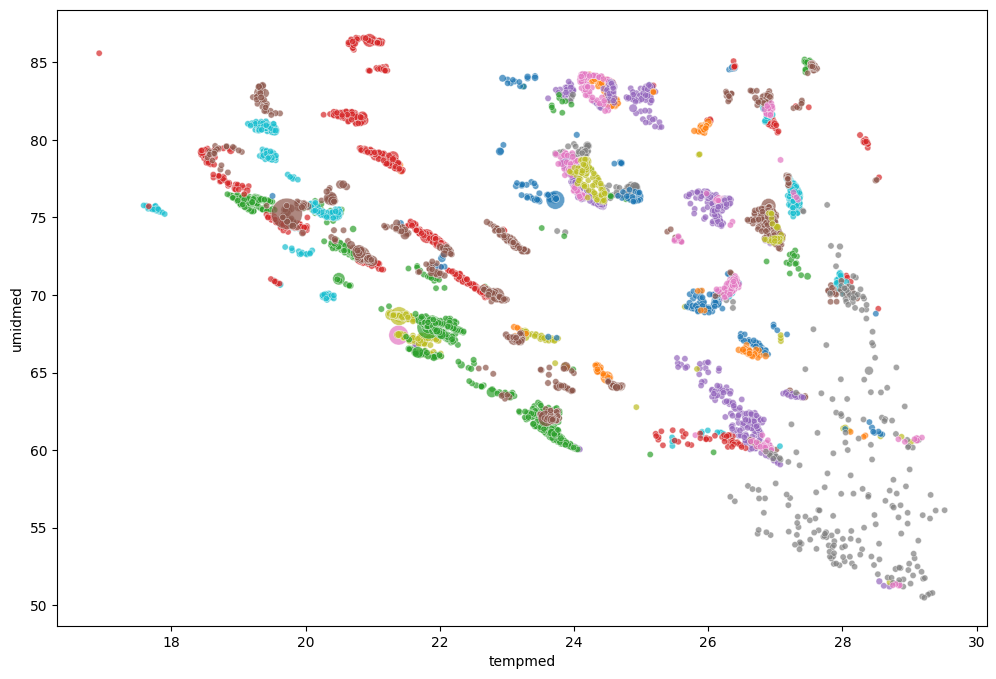

In [28]:
# Teste
dados_completos_mod['data_iniSE'] = pd.to_datetime(dados_completos_mod['data_iniSE'])
dados_completos_mod['ano'] = dados_completos_mod['data_iniSE'].dt.year

df_scatter = (
    dados_completos_mod
    .groupby(['name_state', 'name_muni'], as_index=False)
    .agg({
        'casos': 'sum',
        'umidmed': 'mean',
        'tempmed': 'mean'
    })
    .rename(columns={
        'name_state': 'uf',
        'name_muni': 'municipio'
    })
)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df_scatter,
    x='tempmed',
    y='umidmed',
    size='casos',
    hue='uf',
    palette='tab10',
    alpha=0.7,
    sizes=(20, 500)
)

plt.title('Relação entre Temperatura, Umidade e Casos de Dengue por Município')
plt.xlabel('Temperatura Média (°C)')
plt.ylabel('Umidade Média (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

# DATASUS (SINAN) - Opcional

In [ ]:
# Carrega os arquivos do DATASUS
sinan = SINAN().load

In [ ]:
# Obtendo códigos de doenças
list_diseases()

In [ ]:
# Obtendo anos disponíveis para DENGUE
get_available_years('DENG')

## Extração e Consolidação

In [ ]:
# Diretório
caminho_saida = "/content/drive/MyDrive/Portfólio/Dengue/SINAN_DENGUE_CONSOLIDADO.csv"

# Intervalo de anos
# anos = range(2000, 2026)
anos = range(2025, 2026)

# Remove arquivo antigo, se existir
if os.path.exists(caminho_saida):
    os.remove(caminho_saida)

# Loop processamento
for i, ano in enumerate(anos):
    try:
        # Download pelo PySUS
        parquet_obj = download(diseases='DENG',
                               years=ano)

        # Conversão de .parquet para df pelo PySUS
        df = parquet_obj.to_dataframe()

        # Adiciona no .csv final incrementalmente
        df.to_csv(caminho_saida,
                  mode='a', # Append
                  index=False,
                  header=(i == 0)) # Escreve cabeçalho só no primeiro ano

        print(f"\n✅ Ano {ano} processado e adicionado ao .csv consolidado")

        # Limpa memória
        del df
        gc.collect()

    except Exception as e:
        print(f"Erro no ano {ano}: {e}")

In [ ]:
teste = pd.read_csv(caminho_saida)

In [ ]:
teste.head()